In [1]:
import torch 
from torch_geometric.data import Data
from dataclasses import dataclass
import networkx as nx
import matplotlib.pyplot as plt
import ipaddress
import random


/opt/anaconda3/envs/bigdata/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/anaconda3/envs/bigdata/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Aby stworzyc graf potrzebujemy:
# 1. Krawedzie (edges) - kto jest polaczony z kim 
# 2. Wierzcholki (nodes) - jakie sa cechy wierzch
# 3. (Opcjonalnie) Etykiety (labels) - co chcemy przewidziec

# dla torch_geometric gdy zaimoortujemy Data to potrzebuje parametrów;
# - x - cechy wierzcholkow (nodes)
# - edge_index - krawedzie (edges)
# - y - etykiety (labels)

# nodes = Data(x=x, edge_index=edge_index, y=y)

# gdzie:
# x to macierz cech wierzcholkow,
# edge_index to macierz krawedzi, 
# y to etykiety (labels) dla wierzcholkow lub krawedzi

# np: 
# chcemy stworzyc graf połączeń znajomych w sieci społecznościowej

In [5]:
# kazdy wiersz to dane o osobie np id, ile ma znajomych, ile postów na swoim profilu
x = torch.tensor([
    [1, 3, 5],  # id, liczba znajomych, liczba postów
    [2, 2, 0],
    [3, 5, 10],
    [4, 1, 2],
    [5, 4, 7],
    [6, 0, 1]
])

edge_index = torch.tensor([ # połączenia między osobami (kto jest znajomym kogo)
    [0, 0, 0, 1, 1, 2, 2, 2, 2, 2, 3, 4, 4, 4, 4],
    [1, 2, 4, 0, 3, 0, 1, 3, 4, 5, 1, 0, 2, 3, 5]
], dtype=torch.long)

y = torch.tensor([0, 1, 0, 1, 0, 1])  # etykiety (labels) dla wierzcholkow np: 0 to jest przegryw a 1 to kox

node = Data(x=x, edge_index=edge_index, y=y)
print(node)


Data(x=[6, 3], edge_index=[2, 15], y=[6])


In [8]:
print(node.x)  # cechy wierzcholkow
print(node.edge_index)  # krawedzie
print(node.y)  # etykiety (labels)
print(node.num_nodes)  # liczba wierzcholkow
print(node.num_edges)  # liczba krawedzi

tensor([[ 1,  3,  5],
        [ 2,  2,  0],
        [ 3,  5, 10],
        [ 4,  1,  2],
        [ 5,  4,  7],
        [ 6,  0,  1]])
tensor([[0, 0, 0, 1, 1, 2, 2, 2, 2, 2, 3, 4, 4, 4, 4],
        [1, 2, 4, 0, 3, 0, 1, 3, 4, 5, 1, 0, 2, 3, 5]])
tensor([0, 1, 0, 1, 0, 1])
6
15


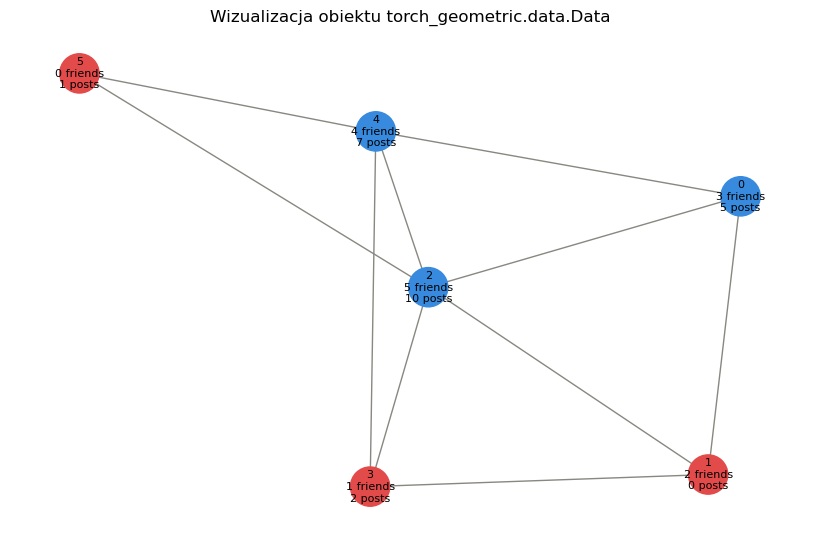

In [9]:
G_node = nx.Graph()
G_node.add_nodes_from(range(node.num_nodes))
G_node.add_edges_from([tuple(edge) for edge in node.edge_index.t().tolist()])

pos_node = nx.spring_layout(G_node, seed=42)

node_colors = ['#378ADD' if int(label) == 0 else '#E24B4A' for label in node.y.tolist()]
node_labels = {i: f"{i}\n{node.x[i,1].item()} friends\n{node.x[i,2].item()} posts" for i in range(node.num_nodes)}

plt.figure(figsize=(8, 5))
nx.draw(
    G_node,
    pos=pos_node,
    with_labels=True,
    labels=node_labels,
    node_color=node_colors,
    node_size=800,
    font_size=8,
    edge_color='#888780'
)
plt.title("Wizualizacja obiektu torch_geometric.data.Data")
plt.show()